In [ ]:
# %pip install numpy matplotlib

In [3]:
import numpy as np 
import matplotlib.pyplot as plt

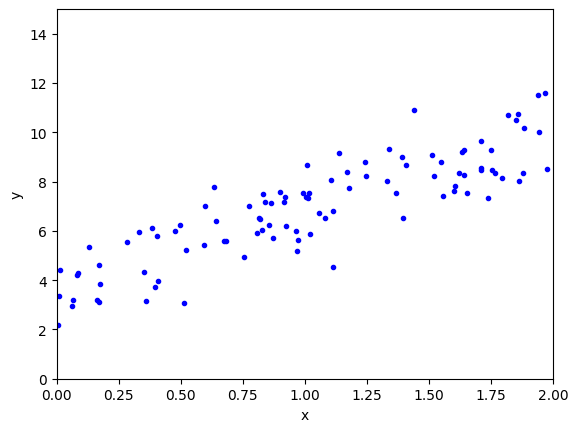

In [ ]:
# Daten
X = 2*np.random.rand(100,1) # gleichmäßige Verteilung zwischen 0 und 2
y = 4 + 3*X + np.random.randn(100,1) # Normalverteilung fürs Rauschen
plt.plot(X,y, "b.")
plt.xlabel("x")
plt.ylabel("y")
plt.axis([0,2,0,15])
plt.show()

In [ ]:
X_b = np.c_[X, np.ones((100,1))]

w = np.array([[3],[4]])

y_hat = X_b @ w # Modell (@ ist Matrizenmultiplikation)
y_hat

# Mini-batch stochastic gradient descent (MBGD)

In [12]:
# Gesucht zahl 3 und zahl 4 
# beste Parameter 
n_epochs = 2000 # 1 Epoche = Der Algorithmus hat 1 Mal den Datensatz gesehen 
m = X.shape[0] # Anzahl der Daten
batch_size = 10 # Ansonsten immer zweier Potenzen 
eta = 0.01 # Lernrate 0<eta<1

w_gd = np.random.randn(2,1) # zufällige Initialisierung 

for epoch in range(n_epochs): # Training-Loop (für alle Epochen)
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices] # Permutationen
    y_shuffled = y[shuffled_indices]
    for i in range(0, m, batch_size):
        xi = X_b_shuffled[i:i+batch_size] # hier wird batch ausgewählt 
        yi = y_shuffled[i:i + batch_size]
        # zwei Zeilen:
        gradients = 2/batch_size*xi.T @ (xi @ w_gd - yi ) # Gradienten ausrechnen / Ableitung von MSE-Loss
        w_gd = w_gd - eta*gradients # Update-Schritt

w_gd

array([[3.14770046],
       [3.7201101 ]])

In [11]:
w

array([[3],
       [4]])